# <b>ADM 3080 — Analítica con Python — Universidad San Francisco de Quito</b>
<h2><b>Proyecto en Clase</b></h2>
<i>Miercoles, 25 de marzo de 2026</i>
<hr>
<ul>
    <li><b>Integrantes del Grupo</b>: Santiago Arellano [00328370]</li>
    <li><b>NRC del Curso</b>: 2041</li>
    <li><b>Profesor</b>: Juan Felipe Nájera Puente</li>
    <li><b>Fecha de Entrega Estimada</b>: Lunes 13 de abril, 2026</li>
</ul>
<hr>

## Sesión 1: Inicio del caso + exploración inicial

En esta sección, que recolecta la información analizada durante la clase 1 del miércoles 25 de marzo, se presenta el caso de estudio y realiza una exploración inicial de la estructura de los datos, cantidades de valores nulos, distribución de los valores nulos y si existe patrones de combinaciones que se puedan explorar para la corrección de los datos. Además se realizará una exploración

### Instalación de Librerias y Carga del Dataset desde GitHub

Para el presente proyecto, se ha optado por trabajar mediante un entorno *managed* de Python a través de *Python Venv(s)* permitiendo el aislamiento de las librerías requeridas para el trabajo. En este contexto, los comandos a ejecutar a continuación se encargan de la instalación de varias librerías para el trabajo, lo que requiere que Python se encuentre instalado y definido dentro del **PATH** o en su caso, en la carpeta de configuración */bin* o */sbin*.
<br><br>
Para la realización del trabajo, se ha considerado necesario la inclusión de diversas librerías. El siguiente listado detalla la razón de la inclusión de la librería en el desarrollo del proyecto:

<div style="display: flex; align-items:center; align-self:center; justify-content:center">
<table style="margin: auto; border-collapse: collapse; width: 80%; text-align: justify; border: 1px solid black;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="border: 1px solid black; padding: 8px;">Librería</th>
            <th style="border: 1px solid black; padding: 8px;">Uso</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Numpy</td>
            <td style="border: 1px solid black; padding: 8px;">Librería de análisis numérico con fuertes características para operaciones algebráicas, matriciales y con un backend implementado en C++ por lo que permitirá la realización de operaciones numéricas rápidamente.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Pandas</td>
            <td style="border: 1px solid black; padding: 8px;">Librería base para el análisis del archivo CSV, su manipulación en forma de carga, datos, y agregaciones que permitirán dar respuesta a las preguntas de investigación definidas.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Matplotlib</td>
            <td style="border: 1px solid black; padding: 8px;">Base de las visualizaciones en el caso de ser necesarias para el desarrollo del proyecto o la exploración visual de los datos.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Seaborn</td>
            <td style="border: 1px solid black; padding: 8px;">Apoyo a Matplotlib en el caso de requerir visualizaciones más avanzadas.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Squarify</td>
            <td style="border: 1px solid black; padding: 8px;">Apoyo a Matplotlib para la realización de Treemaps en Python.</td>
        </tr>
    </tbody>
</table>
</div>
<br><br>
En este contexto, las librerías seran importadas usando un álias al nombre original para facilidad de uso

In [1]:
#? 1. Instalar las librerias desde pip para conectarse con el sistema o el venv generado

%pip install numpy pandas matplotlib seaborn squarify


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
#? 2. Intentamos cargar las librerias
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import squarify
    print("Librerías cargadas correctamente.")
except ImportError as e:
    print("Error en la importancion de datos: ", e.msg)

Librerías cargadas correctamente.


Para el manejo del dataset en el programa, y evitar la necesidad del uso de formatos de directorios extensivos para asegurar la carga de datos, se optó por subir el repositorio completo a GitHub y usar el enlace del archivo csv en formato *RAW* desde la plataforma en el repositorio de libre acceso del proyecto, con esto el sistema puede leer el archivo sin problemas en cualquier dispositivo con acceso a internet.
<br><br>
Para efecto de este proyecto se consideró la creación de una muestra base de los datos bajo el nombre de `data_as_is` que contiene la data tomada desde GitHub como una base que solo será explorada en esta sección, mientras que una *deep copy* de estos datos será usada dentro de la fase de manipulación de los datos y prueba de hipótesis para tener un registro de los datos siempre limpio como *fallback*

In [4]:
#? 1. Carga del dataset mediante GitHub Raw
data_as_is = pd.read_csv("https://raw.githubusercontent.com/Volv1t3/MidtermDataAnalysisProject/refs/heads/main/src/res/data/credit_scoring_eng.csv")

#? 1.1 Copia para exploracion en esta seccion
data_to_explore = data_as_is.copy(deep=True)

#? 1.2 Copia para limpieza del archivo
data_cleaned = data_as_is.copy(deep=True)

### Análisis Estático de las características del dataset

Para esta subsección, se realizará una revisión estática de los campos correspondientes al dataset, estableciendo el tipo de dato esperado bajo una carga dinámica de los datos, y la descripción obtenida de los datos. Este análisis se usará para comparar durante el análisis de nulos, duplicados y tipos de datos, al valor esperado y para informar la toma decisiones sobre eliminaciones de valores nulos, entradas duplicadas y relleno de datos.

<div style="display: flex; align-items:center; align-self:center; justify-content:center">
<table style="margin: auto; border-collapse: collapse; width: 80%; text-align: center; border: 1px solid black;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="border: 1px solid black; padding: 8px;">Campo</th>
            <th style="border: 1px solid black; padding: 8px;">Tipo de Dato Esperado</th>
            <th style="border: 1px solid black; padding: 8px;">Descripción</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">children</td>
            <td style="border: 1px solid black; padding: 8px;">Entero</td>
            <td style="border: 1px solid black; padding: 8px;">El número de hijos en la familia</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">days_employed</td>
            <td style="border: 1px solid black; padding: 8px;">Flotante</td>
            <td style="border: 1px solid black; padding: 8px;">Por cuánto tiempo ha estado trabajando el cliente</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">dob_years</td>
            <td style="border: 1px solid black; padding: 8px;">Entero</td>
            <td style="border: 1px solid black; padding: 8px;">La edad del cliente</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">education</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">El nivel educativo del cliente</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">education_id</td>
            <td style="border: 1px solid black; padding: 8px;">Entero</td>
            <td style="border: 1px solid black; padding: 8px;">Identificador de la educación del cliente</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">family_status</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">Estado civil del cliente</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">family_status_id</td>
            <td style="border: 1px solid black; padding: 8px;">Entero</td>
            <td style="border: 1px solid black; padding: 8px;">Identificador del estado civil del cliente</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">gender</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">El género del cliente</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">income_type</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">El tipo de ingreso del cliente</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">debt</td>
            <td style="border: 1px solid black; padding: 8px;">Binario</td>
            <td style="border: 1px solid black; padding: 8px;">Si el cliente ha incumplido alguna vez un préstamo</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">total_income</td>
            <td style="border: 1px solid black; padding: 8px;">Flotante</td>
            <td style="border: 1px solid black; padding: 8px;">Ingresos mensuales</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">purpose</td>
            <td style="border: 1px solid black; padding: 8px;">Texto</td>
            <td style="border: 1px solid black; padding: 8px;">Motivo por el que se solicita un préstamo</td>
        </tr>
    </tbody>
</table>
</div>

## Exploración inicial: forma, descripcion, informacion, head y tail

En esta subsección se trabajará un análisis primario con las funciones internas de pandas sobre un dataframe para la exploración de los datos de la forma del dataset, al descripción de los datos, el conteo de valores con info y una visualización de datos con head y tail

In [5]:
#? 1. Exploracion de la forma (shape) del dataset
print(f"El dataset tiene {data_as_is.shape[0]} filas")
print(f"El dataset tiene {data_as_is.shape[1]} columnas")

El dataset tiene 21525 filas
El dataset tiene 12 columnas


In [12]:
#? 2. Exploracion de la descripccion del dataset, en este caso primero para las variables numericas
data_as_is.describe(include=["number"])

,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
count,21525.000000,19351.000000,21525.000000,21525.000000,21525.000000,21525.000000,19351.000000
mean,0.538908,63046.497661,43.293380,0.817236,0.972544,0.080883,26787.568355
std,1.381587,140827.311974,12.574584,0.548138,1.420324,0.272661,16475.450632
min,-1.000000,-18388.949901,0.000000,0.000000,0.000000,0.000000,3306.762000
25%,0.000000,-2747.423625,33.000000,1.000000,0.000000,0.000000,16488.504500
50%,0.000000,-1203.369529,42.000000,1.000000,0.000000,0.000000,23202.870000
75%,1.000000,-291.095954,53.000000,1.000000,1.000000,0.000000,32549.611000
max,20.000000,401755.400475,75.000000,4.000000,4.000000,1.000000,362496.645000


In [13]:
#? 2.1 Exploracion de la descripcion del dataset, en caso de las variables de tipo object y string
data_as_is.describe(include=["object","string"])

,education,family_status,gender,income_type,purpose
count,21525,21525,21525,21525,21525
unique,15,5,3,8,38
top,secondary education,married,F,employee,wedding ceremony
freq,13750,12380,14236,11119,797


Hasta este punto notamos que existe un problema grave de valores nulos en las columnas de `days_employed` y `total_income` que se analizará a profundidad en la sección de limpieza de datos, sin embargo, también se puede notar que existen valores negativos en la columna de `days_employed` lo que no tiene sentido lógico, por lo que se deberá analizar si estos valores negativos corresponden a un error de captura o si representan una codificación para los valores nulos, lo que se analizará en la sección de limpieza de datos.

In [14]:
#? 3. Exploracion de la informacion del dataset con info
data_as_is.info()

<class 'pandas.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  str    
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  str    
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  str    
 8   income_type       21525 non-null  str    
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 2.0 MB


En este caso, dado que los datos no son completamente claros mediante `info` o, mediante `describe`, se considera oportuno realizar una sección adicional de análisis completo para cada columna de datos, analizando sus valores internos, distribución, valores únicos, conteos de nulos, etc.

## Drill Down por Atributo: exploración de las características internas del dataset por columna de datos

### Exploración de Children

In [15]:
#? 1. Exploracion de valores unicos en children
print(f"Valores únicos en children: {data_as_is['children'].unique()}")

Valores únicos en children: [ 1  0  3  2 -1  4 20  5]


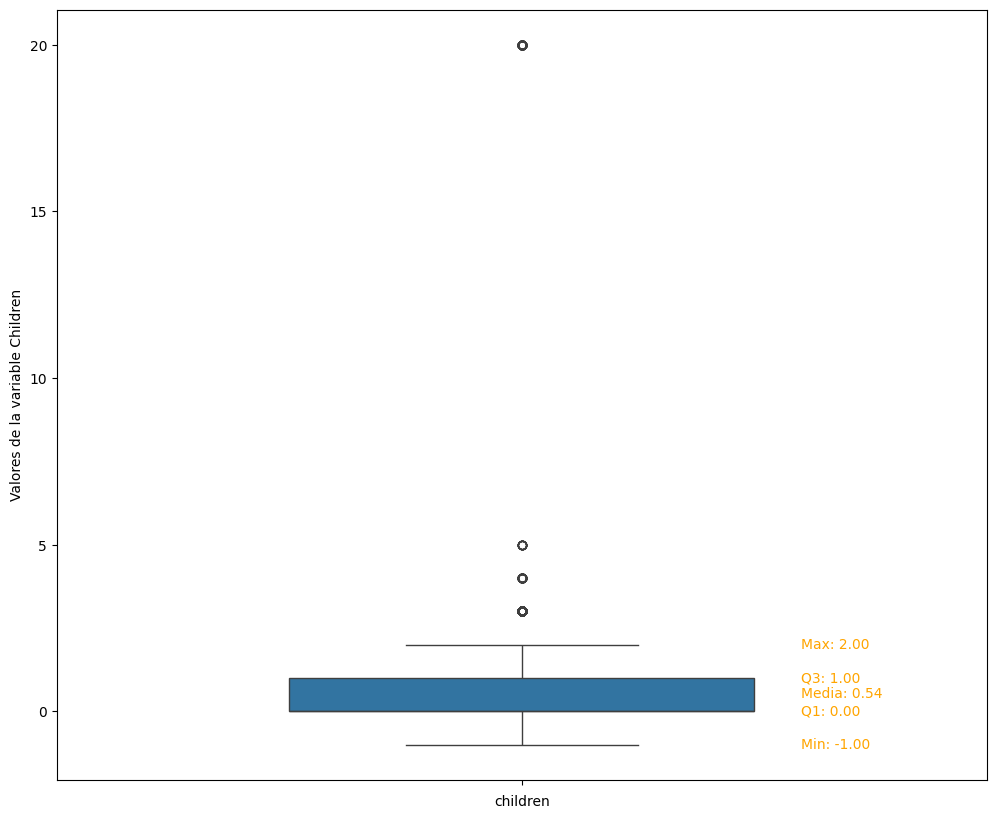

In [37]:
#? 2. Exploracion visual mediante un box plot de los datos del contenido de children
fig, ax = plt.subplots(figsize=(12, 10))
bp = sns.boxplot(data=data_as_is, y='children', ax=ax,width=.50)

# Calcular estadísticas
stats = data_as_is['children'].describe()
q1, median, q3 = stats['25%'], stats['50%'], stats['75%']
mean = stats['mean']
whisker_low = data_as_is['children'][data_as_is['children'] >= q1 - 1.5 * (q3 - q1)].min()
whisker_high = data_as_is['children'][data_as_is['children'] <= q3 + 1.5 * (q3 - q1)].max()

# Anotar cada estadística
for label, val in [("Min", whisker_low), ("Q1", q1), ("Q3", q3), ("Max", whisker_high), ("Media", mean)]:
    ax.annotate(f"{label}: {val:.2f}", xy=(0, val), xytext=(0.3, val),
                fontsize=10, va='center', color='orange')

ax.yaxis.set_label_text("Valores de la variable Children")
ax.set_xlabel("children")
plt.show()


La visualización anterior muestra la situación real de la variable, si bien tenemos datos reales que están registrados entre el Q1 y el Q3, es decir vlaores reales como 1 o 2 hijos, tenemos valores negativos, especificamente tenemos un mínimo de valores con -1 y tenemos un máximo de 20, lo que indica errores de digitación que tiene que ser corregidos.

In [54]:
#? 2.1 Exploracion adicional por tabla de los conteos de valores positivos, en rango, y negativos del dataset para children
result = pd.DataFrame(data={
    "Valores Negativos (< 0)": data_as_is[data_as_is["children"] < 0]["children"].count(),
    "Bajo Whisker Inf (0 a Q1)": data_as_is[(data_as_is["children"] >= 0) & (data_as_is["children"] < q1)]["children"].count(),
    "Q1 a Mediana": data_as_is[(data_as_is["children"] >= q1) & (data_as_is["children"] < median)]["children"].count(),
    "Mediana a Q3": data_as_is[(data_as_is["children"] >= median) & (data_as_is["children"] <= q3)]["children"].count(),
    "Q3 a Whisker Sup": data_as_is[(data_as_is["children"] > q3) & (data_as_is["children"] <= whisker_high)]["children"].count(),
    "Outliers Superiores (> Whisker Sup)": data_as_is[data_as_is["children"] > whisker_high]["children"].count(),
}, index=["Conteo"]).T

for entry in result.index:
    count = result.loc[entry, "Conteo"]
    percentage = (count / data_as_is.shape[0]) * 100
    result.loc[entry, "Percentage"] = percentage
result

,Conteo,Percentage
Valores Negativos (< 0),47,0.218351
Bajo Whisker Inf (0 a Q1),0,0.000000
Q1 a Mediana,0,0.000000
Mediana a Q3,18967,88.116144
Q3 a Whisker Sup,2055,9.547038
Outliers Superiores (> Whisker Sup),456,2.118467


In [43]:
data_as_is['children'].value_counts()

children
 0     14149
 1      4818
 2      2055
 3       330
 20       76
-1        47
 4        41
 5         9
Name: count, dtype: int64

En este caso, podemos notar que existe un conteo de 47 valores negativos en el dataset, si bien es cierto que esto puede haberse considerado como una forma de registrar la ausencia de hijos para una persona que solicitó un préstamo, el valor de cero tiene más sentido en este caso, dado que se usa en el dataset y tiene sentido lógico como un valor en el dataset cuando se habla de hijos. Para aquellos valores que superan por mucho el whisker superior del box plot, ej. las 76 personas cuyo número de hijos se consideró como 20, este tipo de errores de digitación puede referirse específicamente a 2 hijos digitados incorrectamente, o 0 hijos digitados incorrectamente. Por tanto, para la corrección de los datos es importante notar que el valor a reemplazar aquí corresponde a la mediana para garantizar una sanitización de los datos.

En este caso las decisiones exactas para la columna de datos de `children` corresponden a:
1. Para todos los valores superiores del whisker superior, es decir superiores a *2*, se asume verídico los registro para los casos de 3,4 y 5 hijos, pero se asume que es un error de digitación los casos de *20* hijos. Por lo tanto, estos valores serán reemplazados con la mediana del dataset para `children` en este caso 0 para garantizar la sanidad de los datos y reducir el peso de los outliers en el dataset.
2. Para los valores registrados como negativos (i.e. -1) en el dataset, se considera oportuno su modificación a 0 dado que -1 se asume representativo de la ausencia de hijos, que se codifica igual de bien bajo 0 hijos.

### Exploración de days_employed

En este caso esta subsección se centra en el análisis de una de las columnas problemáticas del dataset, que cuenta no solo con valores nulos, sino también con valores negativos ilógicos si se tratara de un conteo de días desde la contratación, a menos que el negativo sea incorrecto y se tenga que restructurar los valores. Para esta exploración se aboradará la exploración desde tres puntos, primero los valores nulos, segundo si los valores son números de conteo de días desde la fecha de contratación y solo hay que corregir el signo, y tercero si son números representativos de una timestamp UNIX de fecha de contratación, lo que también se podría corregir con una transformación de los datos.

In [59]:
#? 1. Exploracion de los valores nulos

result = pd.DataFrame(
    data={
        "Conteo Nulos": data_as_is['days_employed'].isna().sum(),
        "Conteo No Nulos": data_as_is['days_employed'].notna().sum()
    },
    index=['Conteo']
).T

#? 1.1 Anadimos el porcentaje para evaluacion de peso
for entry in result.index:
    conteo = result.loc[entry,'Conteo']
    percentage = (conteo / data_as_is.shape[0] ) * 100
    result.loc[entry,'Percentage'] = percentage
result

,Conteo,Percentage
Conteo Nulos,2174,10.099884
Conteo No Nulos,19351,89.900116
